# 1. Imports

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from transformers import AutoImageProcessor, AutoModelForImageClassification
from torch.utils.data import DataLoader, random_split

from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import json
import random

In [2]:
from huggingface_hub import login
from google.colab import userdata

login(token=userdata.get("HF_TOKEN"))

In [3]:
from transformers import AutoImageProcessor

processor = AutoImageProcessor.from_pretrained(
    'google/vit-base-patch16-224',
    use_fast=True
)

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

In [4]:
#Reproducibility
seed = 42
random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
  device = torch.device('cuda')
elif torch.backends.mps.is_available():
  devide = torch.device('mps')
else:
  device = torch.device('cpu')

print(f'Using device: {device}')

os.makedirs('./models', exist_ok=True)
os.makedirs('./results', exist_ok=True)

Using device: cuda


# 2. Datasets

In [5]:
model_name = 'google/vit-base-patch16-224'
processor = AutoImageProcessor.from_pretrained(model_name)

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=processor.image_mean, std=processor.image_std)
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=processor.image_mean, std=processor.image_std)
])

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


# 3. Load Dataset

In [6]:
full_train_dataset = datasets.OxfordIIITPet(
    root='./data',
    split='trainval',
    target_types='category',
    transform=train_transform,
    download=True
)

test_dataset = datasets.OxfordIIITPet(
    root='./data',
    split='test',
    target_types='category',
    transform=eval_transform,
    download=True
)

class_names = full_train_dataset.classes
num_classes = len(class_names)


100%|██████████| 792M/792M [00:44<00:00, 17.9MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 11.7MB/s]


# 4. Train/Validation Split

In [7]:
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(seed)
)

# Note: validation should not use augmentation.
# Since random_split keeps the same original dataset, we fix this by creating another dataset for validation only.

full_eval_dataset = datasets.OxfordIIITPet(
    root="./data",
    split="trainval",
    target_types="category",
    transform=eval_transform,
    download=True
)

val_dataset.dataset = full_eval_dataset

# 5. DataLoaders

In [8]:
batch_size = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# 6. Create Model

In [18]:
model = AutoModelForImageClassification.from_pretrained(
    model_name,
    num_labels=num_classes,
    ignore_mismatched_sizes=True
)

# Freeze the full ViT first
for param in model.parameters():
    param.requires_grad = False

# Train the classifier head
for param in model.classifier.parameters():
    param.requires_grad = True

# Train only the last ViT encoder block
for param in model.vit.encoder.layer[-1].parameters():
    param.requires_grad = True

model = model.to(device)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())

print(model.classifier)

print(f"Trainable parameters: {trainable_params:,} / {total_params:,}")

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                         
------------------+----------+-----------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([37, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([37])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Linear(in_features=768, out_features=37, bias=True)
Trainable parameters: 7,116,325 / 85,827,109


# 7. Loss, optimizer and scheduler

In [19]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

#optimizer = optim.SGD(model.classifier.parameters(), lr=0.0001, weight_decay=0.0001)

optimizer = optim.AdamW(
    [p for p in model.parameters() if p.requires_grad],
    lr=1e-4,
    weight_decay=5e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=3,
    factor=0.3 # UPDATED FROM 0.5 WITH OPTIMIZER PART FOR EXP3
)

# 8. Training Function

In [20]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(pixel_values=images)
        logits = outputs.logits
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, preds = torch.max(logits, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

# 9. Evaluate

In [21]:
def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(pixel_values=images)
            logits = outputs.logits
            loss = criterion(logits, labels)

            running_loss += loss.item() * images.size(0)

            _, preds = torch.max(logits, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

# 10. Training Loop

In [22]:
num_epochs = 25 # UPDATED FROM 15 FOR EXP3

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "lr": []
}

best_val_acc = 0.0
best_model_path = "./models/exp3_vit_last_block_best.pth"

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    scheduler.step(val_loss)

    current_lr = optimizer.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["lr"].append(current_lr)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"LR: {current_lr:.6f}"
    )

print(f"Best Validation Accuracy: {best_val_acc:.4f}")

Epoch [1/25] Train Loss: 1.6712 | Train Acc: 0.7133 | Val Loss: 0.7806 | Val Acc: 0.8940 | LR: 0.000100
Epoch [2/25] Train Loss: 0.6545 | Train Acc: 0.9276 | Val Loss: 0.6388 | Val Acc: 0.9198 | LR: 0.000100
Epoch [3/25] Train Loss: 0.5520 | Train Acc: 0.9470 | Val Loss: 0.5841 | Val Acc: 0.9375 | LR: 0.000100
Epoch [4/25] Train Loss: 0.5005 | Train Acc: 0.9630 | Val Loss: 0.5818 | Val Acc: 0.9361 | LR: 0.000100
Epoch [5/25] Train Loss: 0.4707 | Train Acc: 0.9766 | Val Loss: 0.5565 | Val Acc: 0.9429 | LR: 0.000100
Epoch [6/25] Train Loss: 0.4537 | Train Acc: 0.9796 | Val Loss: 0.5722 | Val Acc: 0.9402 | LR: 0.000100
Epoch [7/25] Train Loss: 0.4288 | Train Acc: 0.9901 | Val Loss: 0.5546 | Val Acc: 0.9416 | LR: 0.000100
Epoch [8/25] Train Loss: 0.4217 | Train Acc: 0.9912 | Val Loss: 0.5766 | Val Acc: 0.9389 | LR: 0.000100
Epoch [9/25] Train Loss: 0.4091 | Train Acc: 0.9949 | Val Loss: 0.5638 | Val Acc: 0.9389 | LR: 0.000100
Epoch [10/25] Train Loss: 0.4047 | Train Acc: 0.9949 | Val Loss:

***SKIPPED TO STEP 16 FOR EXPERIMENTS BEFORE RUNNING THE REST OF IT.***

# 11. Training Plots

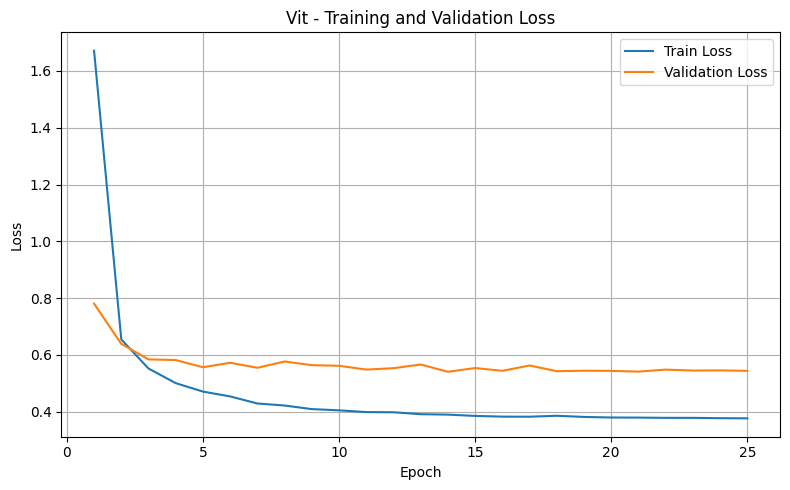

In [23]:
epochs_range = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history["train_loss"], label="Train Loss")
plt.plot(epochs_range, history["val_loss"], label="Validation Loss")
plt.title("Vit - Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("./results/ViT_loss_curve.png", dpi=150)
plt.show()

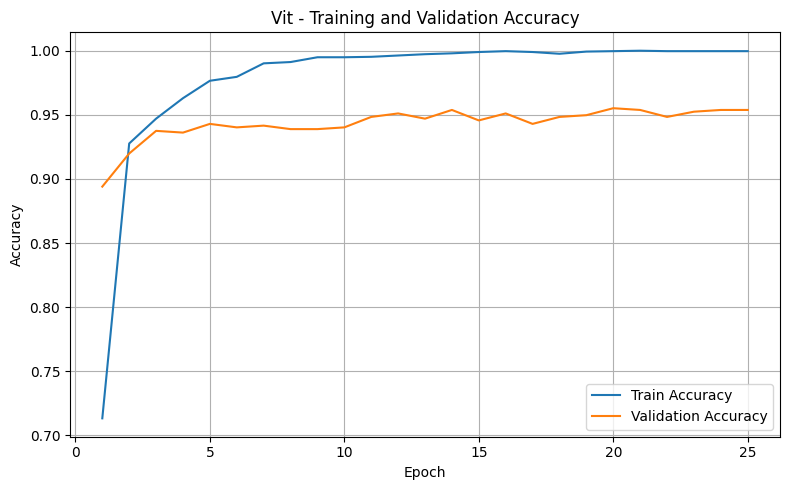

In [24]:
plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history["train_acc"], label="Train Accuracy")
plt.plot(epochs_range, history["val_acc"], label="Validation Accuracy")
plt.title("Vit - Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("./results/ViT_accuracy_curve.png", dpi=150)
plt.show()

# 12. Test Set Evaluation

In [25]:
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.to(device)
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(pixel_values=images)
        logits = outputs.logits
        _, preds = torch.max(logits, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [26]:
test_acc = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average="macro", zero_division=0)
recall = recall_score(all_labels, all_preds, average="macro", zero_division=0)

print(f"Test Accuracy: {test_acc:.4f}")
print(f"Macro Precision: {precision:.4f}")
print(f"Macro Recall: {recall:.4f}")

Test Accuracy: 0.9335
Macro Precision: 0.9352
Macro Recall: 0.9331


# 13. Classification Report

In [27]:
print(classification_report(
    all_labels,
    all_preds,
    target_names=class_names,
    zero_division=0
))

                            precision    recall  f1-score   support

                Abyssinian       0.96      0.96      0.96        98
          American Bulldog       0.80      0.91      0.85       100
 American Pit Bull Terrier       0.83      0.64      0.72       100
              Basset Hound       0.97      0.94      0.95       100
                    Beagle       0.91      0.97      0.94       100
                    Bengal       0.75      0.92      0.83       100
                    Birman       0.81      0.75      0.78       100
                    Bombay       0.92      0.97      0.94        88
                     Boxer       0.93      0.92      0.92        99
         British Shorthair       0.94      0.81      0.87       100
                 Chihuahua       0.95      0.95      0.95       100
              Egyptian Mau       0.94      0.78      0.85        97
    English Cocker Spaniel       0.98      0.96      0.97       100
            English Setter       0.99      0.98

# 14. Confusion Matrix

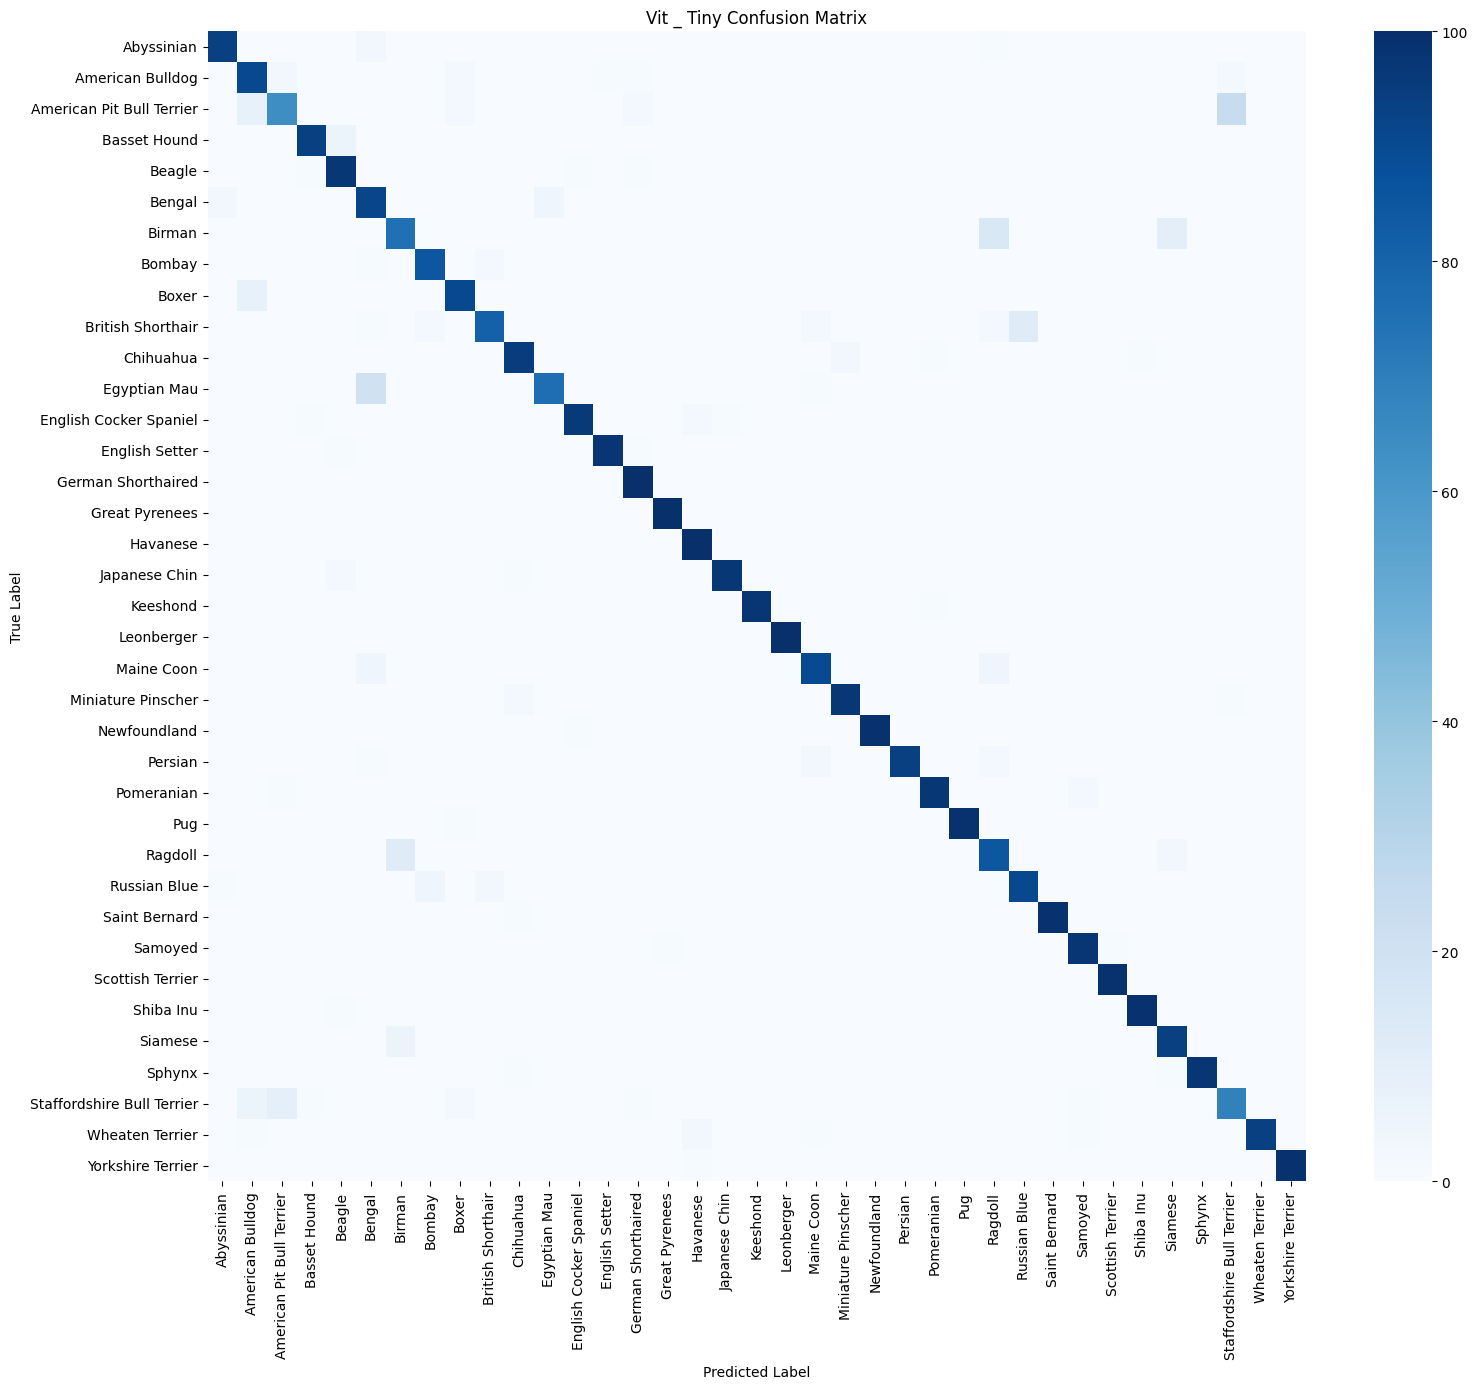

In [28]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(16, 14))

sns.heatmap(
    cm,
    annot=False,
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Vit _ Tiny Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig("./results/ViT_confusion_matrix.png", dpi=150)
plt.show()

# 15. Save Results

In [29]:
results = {
    "model": "ViT google _ Hugging Face",
    "pretrained": True,
    "training_strategy": "last block",
    "image_size": 224,
    "batch_size": batch_size,
    "optimizer": "AdamW",
    "learning_rate": 0.0001,
    "weight_decay": 0.0005,
    "epochs_trained": len(history["train_loss"]),
    "best_validation_accuracy": float(best_val_acc),
    "test_accuracy": float(test_acc),
    "macro_precision": float(precision),
    "macro_recall": float(recall)
}

with open("./results/exp3_vit_last_block_results.json", "w") as f:
    json.dump(results, f, indent=4)

print(json.dumps(results, indent=4))

{
    "model": "ViT google _ Hugging Face",
    "pretrained": true,
    "training_strategy": "last block",
    "image_size": 224,
    "batch_size": 16,
    "optimizer": "AdamW",
    "learning_rate": 0.0001,
    "weight_decay": 0.0005,
    "epochs_trained": 25,
    "best_validation_accuracy": 0.9551630434782609,
    "test_accuracy": 0.9334968656309621,
    "macro_precision": 0.9351671977272857,
    "macro_recall": 0.9330532358644585
}


# 16. Hyperparameter Experiments

The initial feature extractor setup achieved only 72.55% validation accuracy, showing that freezing the entire ViT backbone limited adaptation to the pet classification task. Fine-tuning improved performance significantly across all experiments.

Among the tested strategies:
- Classifier-only tuning already produced strong results (~92% test accuracy).
- Partial fine-tuning (last_block, last_two_blocks) performed best overall, indicating that updating deeper semantic layers helps domain adaptation.
- Full fine-tuning did not outperform last_block, likely due to the small dataset size and increased risk of overfitting.
Strong augmentation slightly improved robustness but did not lead to the highest accuracy.

Overall, partial fine-tuning of the last ViT block provides the best balance between adaptation and generalization for the Oxford-IIIT Pet dataset.

In [15]:
# ============================================================
# EXP-0: Helper — full ViT training function for experiments
# ============================================================

from torch.utils.data import DataLoader, Subset
from transformers import AutoImageProcessor, AutoModelForImageClassification
from sklearn.metrics import precision_score, recall_score
import pandas as pd

EPOCHS_EXP = 30
VIT_MODEL_NAME = "google/vit-base-patch16-224"
processor = AutoImageProcessor.from_pretrained(VIT_MODEL_NAME)


def make_vit_loaders(batch_size, aug="baseline", image_size=224):
    """Create train/val/test loaders for ViT experiments."""

    if aug == "strong":
        tr = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomVerticalFlip(p=0.2),
            transforms.RandomRotation(30),
            transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4),
            transforms.RandomGrayscale(p=0.1),
            transforms.ToTensor(),
            transforms.Normalize(mean=processor.image_mean, std=processor.image_std),
            transforms.RandomErasing(p=0.25)
        ])

    elif aug == "none":
        tr = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=processor.image_mean, std=processor.image_std)
        ])

    else:
        tr = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(15),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
            transforms.ToTensor(),
            transforms.Normalize(mean=processor.image_mean, std=processor.image_std)
        ])

    ev = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=processor.image_mean, std=processor.image_std)
    ])

    tr_full = datasets.OxfordIIITPet(
        root="./data",
        split="trainval",
        target_types="category",
        transform=tr,
        download=False
    )

    ev_full = datasets.OxfordIIITPet(
        root="./data",
        split="trainval",
        target_types="category",
        transform=ev,
        download=False
    )

    te_ds = datasets.OxfordIIITPet(
        root="./data",
        split="test",
        target_types="category",
        transform=ev,
        download=False
    )

    train_indices = train_dataset.indices
    val_indices = val_dataset.indices

    tr_ds = Subset(tr_full, train_indices)
    ev_ds = Subset(ev_full, val_indices)

    trl = DataLoader(tr_ds, batch_size=batch_size, shuffle=True,
                     num_workers=2, pin_memory=True)

    vl = DataLoader(ev_ds, batch_size=batch_size, shuffle=False,
                    num_workers=2, pin_memory=True)

    tel = DataLoader(te_ds, batch_size=batch_size, shuffle=False,
                     num_workers=2, pin_memory=True)

    return trl, vl, tel


def build_vit(strategy="classifier_only", dropout=0.0):
    """Build pretrained ViT and apply selected fine-tuning strategy."""

    m = AutoModelForImageClassification.from_pretrained(
        VIT_MODEL_NAME,
        num_labels=num_classes,
        ignore_mismatched_sizes=True
    )

    for param in m.parameters():
        param.requires_grad = False

    # Optional dropout update
    if hasattr(m.config, "hidden_dropout_prob"):
        m.config.hidden_dropout_prob = dropout
    if hasattr(m.config, "attention_probs_dropout_prob"):
        m.config.attention_probs_dropout_prob = dropout

    # Always train classifier
    for param in m.classifier.parameters():
        param.requires_grad = True

    if strategy == "classifier_only":
        pass

    elif strategy == "last_block":
        for param in m.vit.encoder.layer[-1].parameters():
            param.requires_grad = True

    elif strategy == "last_two_blocks":
        for param in m.vit.encoder.layer[-2:].parameters():
            param.requires_grad = True

    elif strategy == "last_four_blocks":
        for param in m.vit.encoder.layer[-4:].parameters():
            param.requires_grad = True

    elif strategy == "full_finetune":
        for param in m.parameters():
            param.requires_grad = True

    else:
        raise ValueError(
            "strategy must be: classifier_only, last_block, "
            "last_two_blocks, last_four_blocks, full_finetune"
        )

    return m.to(device)


def run_vit_experiment(
    name,
    lr,
    batch_size,
    dropout,
    aug,
    strategy="classifier_only",
    optimizer_type="adamw",
    wd=1e-4,
    image_size=224,
    epochs=EPOCHS_EXP,
    label_smoothing=0.05,
    scheduler_type="plateau"
):
    """Train ViT with selected hyperparameters and return result dict."""

    print(f"\n{'='*70}")
    print(f"  EXP: {name}")
    print(f"  strategy={strategy} | lr={lr} | batch={batch_size} | dropout={dropout}")
    print(f"  aug={aug} | opt={optimizer_type} | wd={wd} | image_size={image_size}")
    print(f"{'='*70}")

    m = build_vit(strategy=strategy, dropout=dropout)

    trl, vl, tel = make_vit_loaders(
        batch_size=batch_size,
        aug=aug,
        image_size=image_size
    )

    trainable_params = [p for p in m.parameters() if p.requires_grad]

    if optimizer_type == "sgd":
        opt = optim.SGD(trainable_params, lr=lr, momentum=0.9, weight_decay=wd)
    elif optimizer_type == "adam":
        opt = optim.Adam(trainable_params, lr=lr, weight_decay=wd)
    else:
        opt = optim.AdamW(trainable_params, lr=lr, weight_decay=wd)

    crit = nn.CrossEntropyLoss(label_smoothing=label_smoothing)

    if scheduler_type == "cosine":
        sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    elif scheduler_type == "plateau":
        sched = optim.lr_scheduler.ReduceLROnPlateau(
            opt, mode="min", factor=0.3, patience=3
        )
    else:
        sched = None

    best_val = 0.0
    best_path = f"./models/{name}_best.pth"

    for epoch in range(epochs):
        tr_loss, tr_acc = train_one_epoch(m, trl, crit, opt, device)
        vl_loss, vl_acc = evaluate(m, vl, crit, device)

        if scheduler_type == "plateau":
            sched.step(vl_loss)
        elif sched is not None:
            sched.step()

        if vl_acc > best_val:
            best_val = vl_acc
            torch.save(m.state_dict(), best_path)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(
                f"  Epoch {epoch+1}/{epochs} | "
                f"train_acc={tr_acc:.4f} | "
                f"val_acc={vl_acc:.4f} | "
                f"best={best_val:.4f}"
            )

    m.load_state_dict(torch.load(best_path, map_location=device))

    _, test_acc = evaluate(m, tel, crit, device)

    all_preds = []
    all_labels = []

    m.eval()
    with torch.no_grad():
        for images, labels in tel:
            images = images.to(device)
            labels = labels.to(device)

            outputs = m(pixel_values=images)
            logits = outputs.logits
            _, preds = torch.max(logits, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    precision = precision_score(all_labels, all_preds, average="macro", zero_division=0)
    recall = recall_score(all_labels, all_preds, average="macro", zero_division=0)

    print(f"  >>> FINAL best_val={best_val:.4f} | test_acc={test_acc:.4f}")

    return {
        "name": name,
        "model": "ViT Base Patch16 224",
        "pretrained": True,
        "strategy": strategy,
        "image_size": image_size,
        "lr": lr,
        "batch_size": batch_size,
        "dropout": dropout,
        "augmentation": aug,
        "optimizer": optimizer_type,
        "weight_decay": wd,
        "epochs": epochs,
        "label_smoothing": label_smoothing,
        "scheduler": scheduler_type,
        "best_val_acc": round(best_val, 4),
        "test_acc": round(test_acc, 4),
        "macro_precision": round(precision, 4),
        "macro_recall": round(recall, 4)
    }


vit_exp_results = []
print("ViT experiment helpers ready.")

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


ViT experiment helpers ready.


In [16]:
# ============================================================
# EXP-1 to EXP-5: ViT experiments
# ============================================================

vit_exp_results.append(run_vit_experiment(
    name="exp1_vit_classifier_lr1e3",
    lr=1e-3,
    batch_size=16,
    dropout=0.1,
    aug="baseline",
    strategy="classifier_only",
    optimizer_type="adamw",
    wd=1e-4,
    epochs=20
))

vit_exp_results.append(run_vit_experiment(
    name="exp2_vit_classifier_strong_aug",
    lr=5e-4,
    batch_size=16,
    dropout=0.2,
    aug="strong",
    strategy="classifier_only",
    optimizer_type="adamw",
    wd=5e-4,
    epochs=20
))

vit_exp_results.append(run_vit_experiment(
    name="exp3_vit_last_block",
    lr=1e-4,
    batch_size=16,
    dropout=0.1,
    aug="baseline",
    strategy="last_block",
    optimizer_type="adamw",
    wd=5e-4,
    epochs=25
))

vit_exp_results.append(run_vit_experiment(
    name="exp4_vit_last_two_blocks",
    lr=5e-5,
    batch_size=8,
    dropout=0.2,
    aug="baseline",
    strategy="last_two_blocks",
    optimizer_type="adamw",
    wd=1e-3,
    epochs=30
))

vit_exp_results.append(run_vit_experiment(
    name="exp5_vit_full_finetune",
    lr=1e-5,
    batch_size=8,
    dropout=0.2,
    aug="strong",
    strategy="full_finetune",
    optimizer_type="adamw",
    wd=1e-3,
    epochs=30
))


  EXP: exp1_vit_classifier_lr1e3
  strategy=classifier_only | lr=0.001 | batch=16 | dropout=0.1
  aug=baseline | opt=adamw | wd=0.0001 | image_size=224


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                         
------------------+----------+-----------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([37, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([37])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


  Epoch 1/20 | train_acc=0.8370 | val_acc=0.9212 | best=0.9212
  Epoch 5/20 | train_acc=0.9800 | val_acc=0.9389 | best=0.9389
  Epoch 10/20 | train_acc=0.9946 | val_acc=0.9429 | best=0.9429
  Epoch 15/20 | train_acc=0.9963 | val_acc=0.9375 | best=0.9429
  Epoch 20/20 | train_acc=0.9990 | val_acc=0.9429 | best=0.9457
  >>> FINAL best_val=0.9457 | test_acc=0.9229

  EXP: exp2_vit_classifier_strong_aug
  strategy=classifier_only | lr=0.0005 | batch=16 | dropout=0.2
  aug=strong | opt=adamw | wd=0.0005 | image_size=224


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

...

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                         
------------------+----------+-----------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([37, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([37])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


  Epoch 1/30 | train_acc=0.7412 | val_acc=0.9253 | best=0.9253
  Epoch 5/30 | train_acc=0.9861 | val_acc=0.9524 | best=0.9524
  Epoch 10/30 | train_acc=0.9959 | val_acc=0.9402 | best=0.9524
  Epoch 15/30 | train_acc=0.9997 | val_acc=0.9470 | best=0.9524
  Epoch 20/30 | train_acc=1.0000 | val_acc=0.9470 | best=0.9524
  Epoch 25/30 | train_acc=1.0000 | val_acc=0.9470 | best=0.9524
  Epoch 30/30 | train_acc=0.9997 | val_acc=0.9470 | best=0.9524
  >>> FINAL best_val=0.9524 | test_acc=0.9289

  EXP: exp5_vit_full_finetune
  strategy=full_finetune | lr=1e-05 | batch=8 | dropout=0.2
  aug=strong | opt=adamw | wd=0.001 | image_size=224


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                         
------------------+----------+-----------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([37, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([37])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


  Epoch 1/30 | train_acc=0.3404 | val_acc=0.7595 | best=0.7595
  Epoch 5/30 | train_acc=0.9086 | val_acc=0.9361 | best=0.9361
  Epoch 10/30 | train_acc=0.9558 | val_acc=0.9511 | best=0.9524
  Epoch 15/30 | train_acc=0.9735 | val_acc=0.9457 | best=0.9524
  Epoch 20/30 | train_acc=0.9732 | val_acc=0.9524 | best=0.9552
  Epoch 25/30 | train_acc=0.9779 | val_acc=0.9524 | best=0.9552
  Epoch 30/30 | train_acc=0.9772 | val_acc=0.9511 | best=0.9552
  >>> FINAL best_val=0.9552 | test_acc=0.9283


In [17]:
# ============================================================
# FINAL RESULTS TABLE
# ============================================================

import pandas as pd

df_vit_exp = pd.DataFrame(vit_exp_results)
df_vit_exp = df_vit_exp.sort_values(by="test_acc", ascending=False)

display(df_vit_exp)

df_vit_exp.to_csv("./results/vit_experiment_results.csv", index=False)

with open("./results/vit_experiment_results.json", "w") as f:
    json.dump(vit_exp_results, f, indent=4)

print("Saved ViT experiment results.")

,name,model,pretrained,strategy,image_size,lr,batch_size,dropout,augmentation,optimizer,weight_decay,epochs,label_smoothing,scheduler,best_val_acc,test_acc,macro_precision,macro_recall
2,exp3_vit_last_block,ViT Base Patch16 224,True,last_block,224,0.00010,16,0.1,baseline,adamw,0.0005,25,0.05,plateau,0.9552,0.9316,0.9330,0.9309
3,exp4_vit_last_two_blocks,ViT Base Patch16 224,True,last_two_blocks,224,0.00005,8,0.2,baseline,adamw,0.0010,30,0.05,plateau,0.9524,0.9289,0.9307,0.9286
4,exp5_vit_full_finetune,ViT Base Patch16 224,True,full_finetune,224,0.00001,8,0.2,strong,adamw,0.0010,30,0.05,plateau,0.9552,0.9283,0.9295,0.9280
0,exp1_vit_classifier_lr1e3,ViT Base Patch16 224,True,classifier_only,224,0.00100,16,0.1,baseline,adamw,0.0001,20,0.05,plateau,0.9457,0.9229,0.9248,0.9227
1,exp2_vit_classifier_strong_aug,ViT Base Patch16 224,True,classifier_only,224,0.00050,16,0.2,strong,adamw,0.0005,20,0.05,plateau,0.9402,0.9191,0.9203,0.9186


Saved ViT experiment results.


The best overall approach is EXP3: last_block fine-tuning.

Best Approach
- Experiment: exp3_vit_last_block
- Strategy: last_block
- Validation Accuracy: 0.9552
- Test Accuracy: 0.9316 (highest test accuracy)

This approach gives the best generalization performance because it achieves the highest test accuracy while maintaining top validation accuracy. Fine-tuning only the last transformer block allows the model to adapt to the Oxford-IIIT Pet dataset without overfitting the pretrained ViT representations.